In [6]:
import torch
from torch.utils.data import DataLoader

from shapenet_dataset import ShapeNetDataset
from visualize import plot_pointclouds, visualize_reconstructions

# autoreload py
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data Loading & Visualization

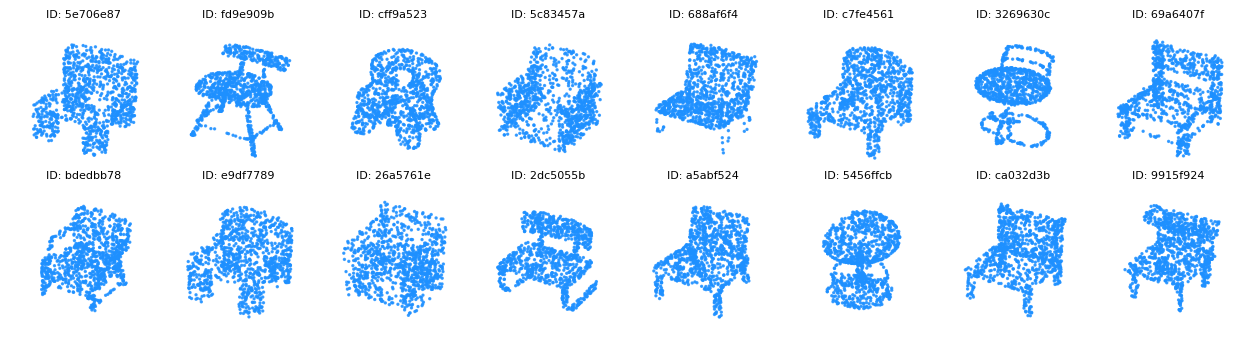

In [7]:
# raw mesh loader was very slow, precompute pointcloud as .npy instead
# dataset = ShapeNetDataset(data_dir='/ist/ist-share/scads/ploy/scene2/big_file/shapenet/shapenet/', object_class='03001627', num_points=1024)

dataset = ShapeNetDataset(data_dir='./sampled_poincloud/', object_class='03001627')
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# plot 3d scatter of first batch
for batch in dataloader:
    pcs = batch['points']  # shape (B, N, 3)
    ids = batch['object_id']
    pc_list = list(zip(ids, pcs))
    plot_pointclouds(pc_list, n_cols=8)
    break

## Experiment Flow

- Define model and loss directly in this notebook for each experiment.
- Use `run_training(...)` from `experiment_runner.py` for training loop, checkpoints, metrics, tqdm, and optional wandb.

## Experiment List
- Baseline 1: Base model (no seed), Loss: Chamfer.
- Baseline 2: Base model (no seed), Loss: Chamfer + Repulsion.

## Setting up

In [8]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from model import PointCloudAE
from pytorch3d.loss import chamfer_distance
import numpy as np

from experiment_runner import ExperimentConfig, run_training

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Shared configs for all runs
z_dim = 1024
batch_size = 16
num_epochs = 100
lr = 1e-3
val_split = 0.1
seed = 42

# Notebook-safe default: multiprocessing DataLoader workers can trigger
# "can only test a child process" cleanup errors in Jupyter.
num_workers = 0

torch.manual_seed(seed)
np.random.seed(seed)

num_points = dataset[0]["points"].shape[0]
all_indices = np.arange(len(dataset))
train_idx, val_idx = train_test_split(
    all_indices, test_size=val_split, random_state=seed, shuffle=True
)
train_set = Subset(dataset, train_idx)
val_set = Subset(dataset, val_idx)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers,
    pin_memory=(device == "cuda"),
)
val_loader = DataLoader(
    val_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=(device == "cuda"),
)

device: cuda


## Baseline 1

In [9]:
import wandb
# wandb.login(key="")

In [10]:
# 1) Baseline experiment: Chamfer Distance only
model_cd = PointCloudAE(z_dim=z_dim, num_points=num_points)
optimizer_cd = torch.optim.Adam(model_cd.parameters(), lr=lr)
loss_fn_cd = lambda recon, points: chamfer_distance(
    recon.float(),
    points.float(),
    batch_reduction="mean",
    point_reduction="mean",
)[0]

cfg_cd = ExperimentConfig(
    name="baseline_cd",
    num_epochs=num_epochs,
    seed=seed,
    use_amp=True,
    save_every=10,
    run_root="runs",
    epoch_log_every=10,
)

run_dir_cd, summary_cd = run_training(
    config=cfg_cd,
    model=model_cd,
    optimizer=optimizer_cd,
    loss_fn=loss_fn_cd,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
)
print("Baseline CD run dir:", run_dir_cd)
print("Baseline CD summary:", summary_cd)

train:baseline_cd:   0%|          | 0/42500 [00:00<?, ?it/s]

[baseline_cd] epoch 010/100 train 0.004915 val 0.005177 best 0.005177
[baseline_cd] epoch 020/100 train 0.004069 val 0.004277 best 0.004277
[baseline_cd] epoch 030/100 train 0.003623 val 0.004151 best 0.004111
[baseline_cd] epoch 040/100 train 0.003402 val 0.004001 best 0.003946
[baseline_cd] epoch 050/100 train 0.003186 val 0.003964 best 0.003937
[baseline_cd] epoch 060/100 train 0.003065 val 0.003916 best 0.003885
[baseline_cd] epoch 070/100 train 0.002973 val 0.003923 best 0.003879
[baseline_cd] epoch 080/100 train 0.002916 val 0.003964 best 0.003868
[baseline_cd] epoch 090/100 train 0.002883 val 0.003917 best 0.003868
[baseline_cd] epoch 100/100 train 0.002827 val 0.003900 best 0.003868
Baseline CD run dir: runs/20260424-154438_baseline_cd
Baseline CD summary: {'best_val': 0.003868058026053531, 'best_epoch': 74}


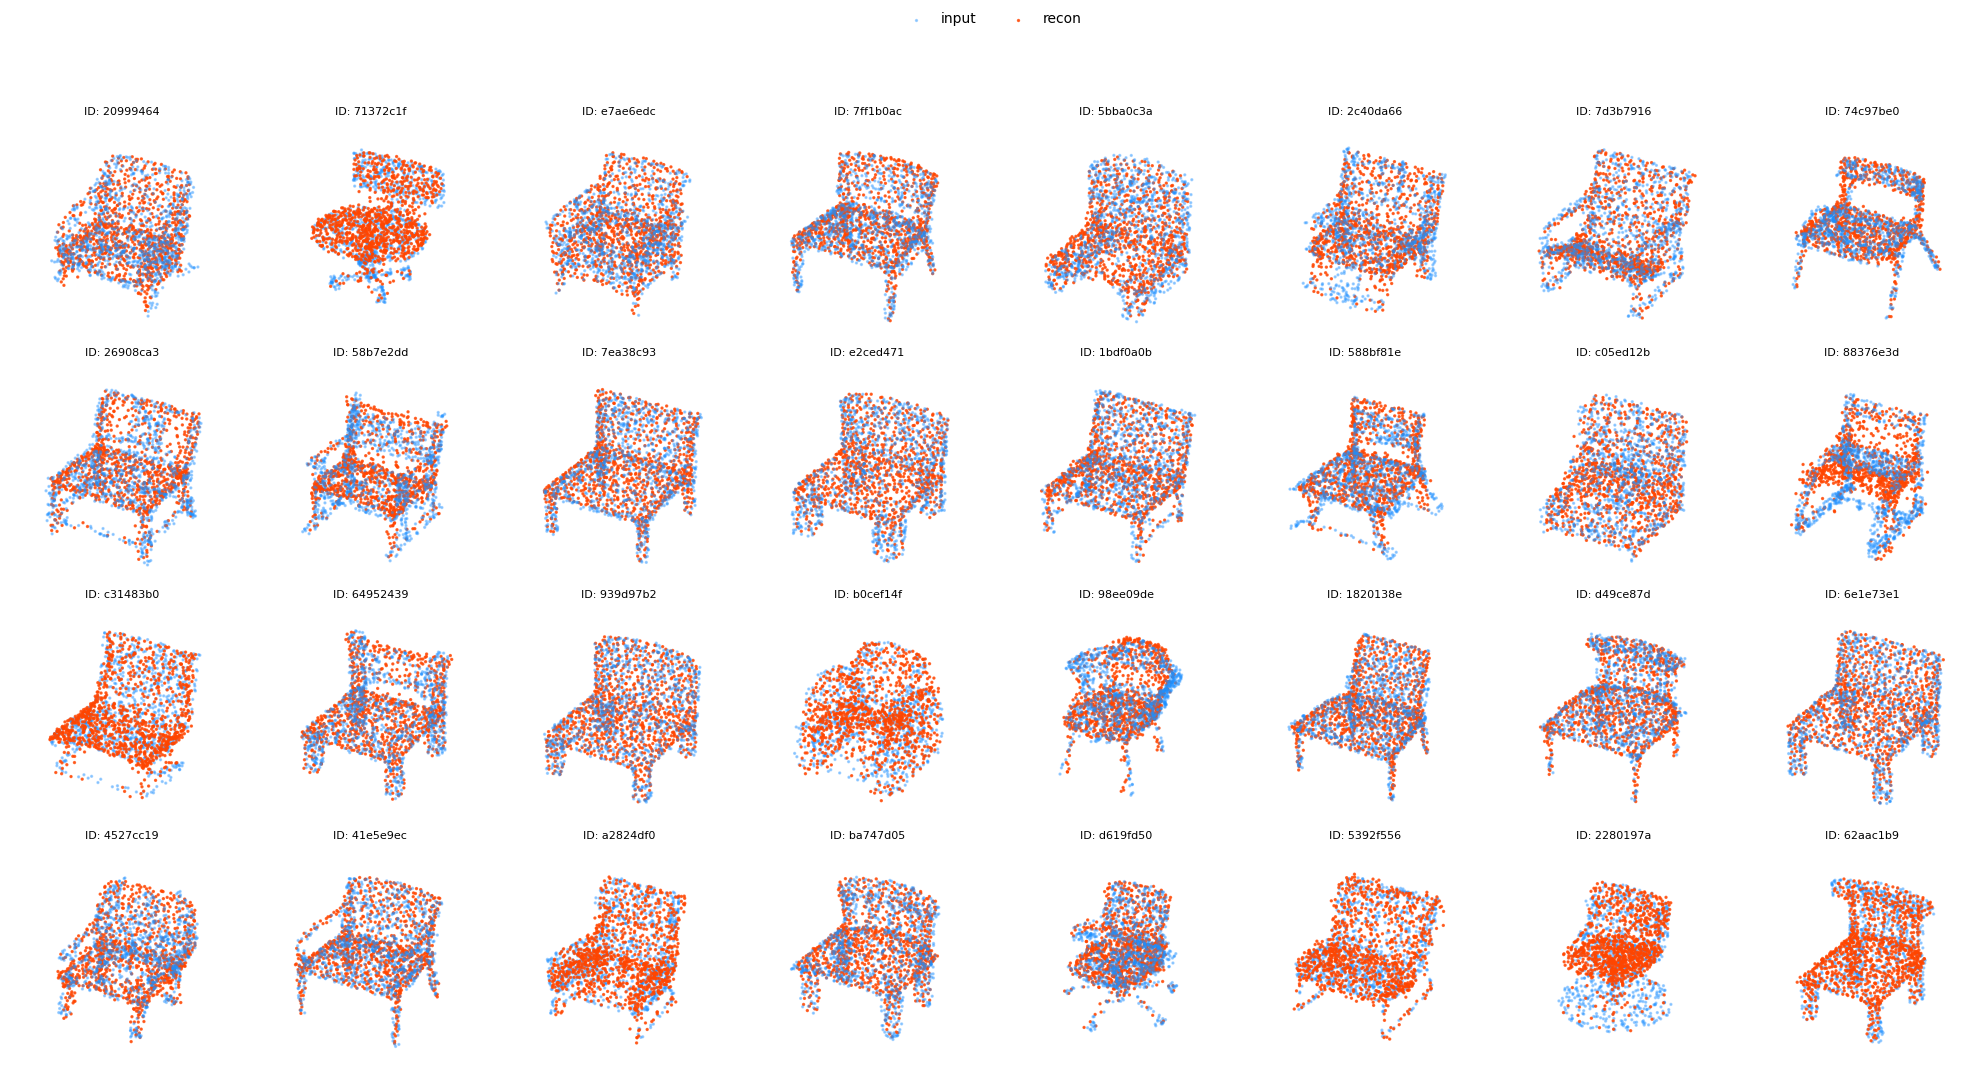

In [11]:
# Visualize baseline reconstructions across N validation batches
visualize_reconstructions(
    model=model_cd,
    loader=val_loader,
    device=device,
    num_batches=2,
    n_cols=8,
)

In [ ]:
# 2) Baseline skeleton: Chamfer + Repulsion
# Keep model/optimizer definitions explicit; only loss changes.
model_rep = PointCloudAE(z_dim=z_dim, num_points=num_points)
optimizer_rep = torch.optim.Adam(model_rep.parameters(), lr=lr)

def repulsion_loss_placeholder(_pred_points):
    # TODO: implement your repulsion loss here.
    raise NotImplementedError("Implement repulsion loss before running this experiment")

def loss_fn_cd_plus_repulsion(recon, points):
    cd = chamfer_distance(
        recon,
        points,
        batch_reduction="mean",
        point_reduction="mean",
    )[0]
    rep = repulsion_loss_placeholder(recon)
    return cd + 0.1 * rep

cfg_cd_rep = ExperimentConfig(
    name="baseline_cd_plus_repulsion_skeleton",
    num_epochs=num_epochs,
    seed=seed,
    use_amp=True,
    save_every=10,
    run_root="runs",
)

print("Repulsion skeleton ready: implement repulsion_loss_placeholder, then uncomment run.")
# run_dir_rep, summary_rep = run_training(
#     config=cfg_cd_rep,
#     model=model_rep,
#     optimizer=optimizer_rep,
#     loss_fn=loss_fn_cd_plus_repulsion,
#     train_loader=train_loader,
#     val_loader=val_loader,
#     device=device,
# )